In [ ]:
import os
print(os.listdir("/content"))

['.config', 'archive (3).zip', 'sample_data']


In [ ]:
from pathlib import Path
from zipfile import ZipFile

zip_path = Path("/content/archive (3).zip")

with ZipFile(zip_path) as arquivo:
    nomes = arquivo.namelist()
    print("Ficheiros no ZIP:", len(nomes))
    print("\nPrimeiros 10 caminhos:")
    for nome in nomes[:10]:
        print(nome)

Ficheiros no ZIP: 1130

Primeiros 10 caminhos:
Bone Break Classification/Bone Break Classification/Avulsion fracture/Test/000002_png.rf.c3e00ebc2db78bc94e644c3f6605dad0.jpg
Bone Break Classification/Bone Break Classification/Avulsion fracture/Test/05cc2e0302957e0ad27edb6b9ffbc2_jumbo_jpg.rf.c15eb3758845b639f3aaba73c373501d.jpg
Bone Break Classification/Bone Break Classification/Avulsion fracture/Test/1-s2-0-S0899707114002836-gr2_jpg.rf.bb8ed4dee892edbb760f6ce687d74ba5.jpg
Bone Break Classification/Bone Break Classification/Avulsion fracture/Test/13256_2019_2325_Fig1_HTML_png.rf.09368fddb2da3979a35a0cac6f45.jpg
Bone Break Classification/Bone Break Classification/Avulsion fracture/Test/13256_2019_2325_Fig1_HTML_png.rf.09368fddb2da3979a3e1e25a0cac6f45.jpg
Bone Break Classification/Bone Break Classification/Avulsion fracture/Test/1b62e6fbfbc5a2f70c6af413189cfc82_jpg.rf.2761e933cc6d206308877cccaf0642b2.jpg
Bone Break Classification/Bone Break Classification/Avulsion fracture/Test/220px-Avul

In [ ]:
from pathlib import Path
from zipfile import ZipFile
from collections import Counter

destino = Path("/content/bone_break_data")

with ZipFile("/content/archive (3).zip") as arquivo:
    arquivo.extractall(destino)

raiz = destino / "Bone Break Classification" / "Bone Break Classification"
extensoes = {".jpg", ".jpeg", ".png", ".webp"}

contagens = Counter(
    (imagem.parent.parent.name, imagem.parent.name)
    for imagem in raiz.rglob("*")
    if imagem.is_file() and imagem.suffix.lower() in extensoes
)

print("Total de imagens:", sum(contagens.values()))
print("Número de classes:", len({classe for classe, _ in contagens}))

for (classe, divisao), quantidade in sorted(contagens.items()):
    print(f"{classe} | {divisao}: {quantidade}")

Total de imagens: 1129
Número de classes: 10
Avulsion fracture | Test: 14
Avulsion fracture | Train: 109
Comminuted fracture | Test: 14
Comminuted fracture | Train: 134
Fracture Dislocation | Test: 19
Fracture Dislocation | Train: 137
Greenstick fracture | Test: 16
Greenstick fracture | Train: 106
Hairline Fracture | Test: 10
Hairline Fracture | Train: 101
Impacted fracture | Test: 9
Impacted fracture | Train: 75
Longitudinal fracture | Test: 12
Longitudinal fracture | Train: 68
Oblique fracture | Test: 16
Oblique fracture | Train: 69
Pathological fracture | Test: 18
Pathological fracture | Train: 116
Spiral Fracture | Test: 12
Spiral Fracture | Train: 74


In [ ]:
import hashlib
from collections import defaultdict

por_hash = defaultdict(list)

for imagem in raiz.rglob("*"):
    if imagem.is_file() and imagem.suffix.lower() in extensoes:
        hash_imagem = hashlib.sha256(imagem.read_bytes()).hexdigest()
        por_hash[hash_imagem].append(imagem)

grupos_repetidos = [
    caminhos for caminhos in por_hash.values()
    if len(caminhos) > 1
]

print("Grupos de imagens exatamente iguais:", len(grupos_repetidos))

for grupo in grupos_repetidos:
    print("\nRepetição:")
    for caminho in grupo:
        print(" ", caminho.relative_to(raiz))

Grupos de imagens exatamente iguais: 3

Repetição:
  Avulsion fracture/Train/35765-galleyfig1a_jpeg.rf.4e4f1d462790773a110b4171d25a.jpg
  Avulsion fracture/Train/35765-galleyfig1a_jpeg.rf62790773a110b4171d25a.jpg

Repetição:
  Greenstick fracture/Train/Comparison-imaginactug9d8d0f5e1ae7b77ee6efceaf5a1386.jpg
  Greenstick fracture/Train/Comparison-imaginactug8d0f5e1ae7b77ee6efceaf5a1386.jpg

Repetição:
  Fracture Dislocation/Train/ot1020_otgr_f1_og_jpg.r458090596504941ee7e64eb43f41a.jpg
  Fracture Dislocation/Train/ot1020_otgr_f1_og_jpg.r458090596504941eefb7e64eb43f41a.jpg


In [ ]:
from PIL import Image

def dhash(caminho):
    with Image.open(caminho) as imagem:
        cinzento = imagem.convert("L").resize((9, 8))
        pixels = list(cinzento.getdata())
    return sum(
        (pixels[y * 9 + x] > pixels[y * 9 + x + 1]) << (y * 8 + x)
        for y in range(8) for x in range(8)
    )

treino = [
    p for p in raiz.rglob("*")
    if p.is_file() and p.suffix.lower() in extensoes and p.parent.name == "Train"
]
teste = [
    p for p in raiz.rglob("*")
    if p.is_file() and p.suffix.lower() in extensoes and p.parent.name == "Test"
]

hashes_treino = [(p, dhash(p)) for p in treino]
hashes_teste = [(p, dhash(p)) for p in teste]

suspeitas = sorted(
    (
        ((h1 ^ h2).bit_count(), p1, p2)
        for p1, h1 in hashes_treino
        for p2, h2 in hashes_teste
        if (h1 ^ h2).bit_count() <= 4
    ),
    key=lambda item: item[0]
)

print("Pares semelhantes entre Train e Test:", len(suspeitas))
for distancia, p1, p2 in suspeitas[:20]:
    print(distancia, "|", p1.relative_to(raiz), "|", p2.relative_to(raiz))

Pares semelhantes entre Train e Test: 104
0 | Longitudinal fracture/Train/image11_jpeg.rf.84f417f2d5f60cb01cbc6f4835e596a2.jpg | Longitudinal fracture/Test/7d6985744a7187e8af927146b0c2425e_f12207_jpg.rf.2fc543dad580f8ea8d7d4105ca8e4300.jpg
0 | Longitudinal fracture/Train/image19_jpeg.rf.883f4884d8d4b625872a61ff5333c797.jpg | Longitudinal fracture/Test/488c4ff0bb5278bbf87f4c0e981dd6_gallery_jpg.rf.87d2f936037e0dfc1614f7518316a543.jpg
0 | Longitudinal fracture/Train/image14_jpeg.rf.e7c94e1a17c793fbaf3c607c4904561b.jpg | Longitudinal fracture/Test/35d36ae9df9a48426f94b75d0f2939_jumbo_jpeg.rf.c0eebf1735c43ba5de01d321ce10748a.jpg
0 | Comminuted fracture/Train/images27_jpg.rf.a40da5235aba28054fc8c4685700b70b.jpg | Longitudinal fracture/Test/35d36ae9df9a48426f94b75d0f2939_jumbo_jpeg.rf.c0eebf1735c43ba5de01d321ce10748a.jpg
0 | Comminuted fracture/Train/image15_jpeg.rf.cbc07b69b6bdfe826b7dbcbc6264b087.jpg | Comminuted fracture/Test/X-ray-2-comminuted-displaced-fracture_png.rf.ace79e6f0ec1e6ec40

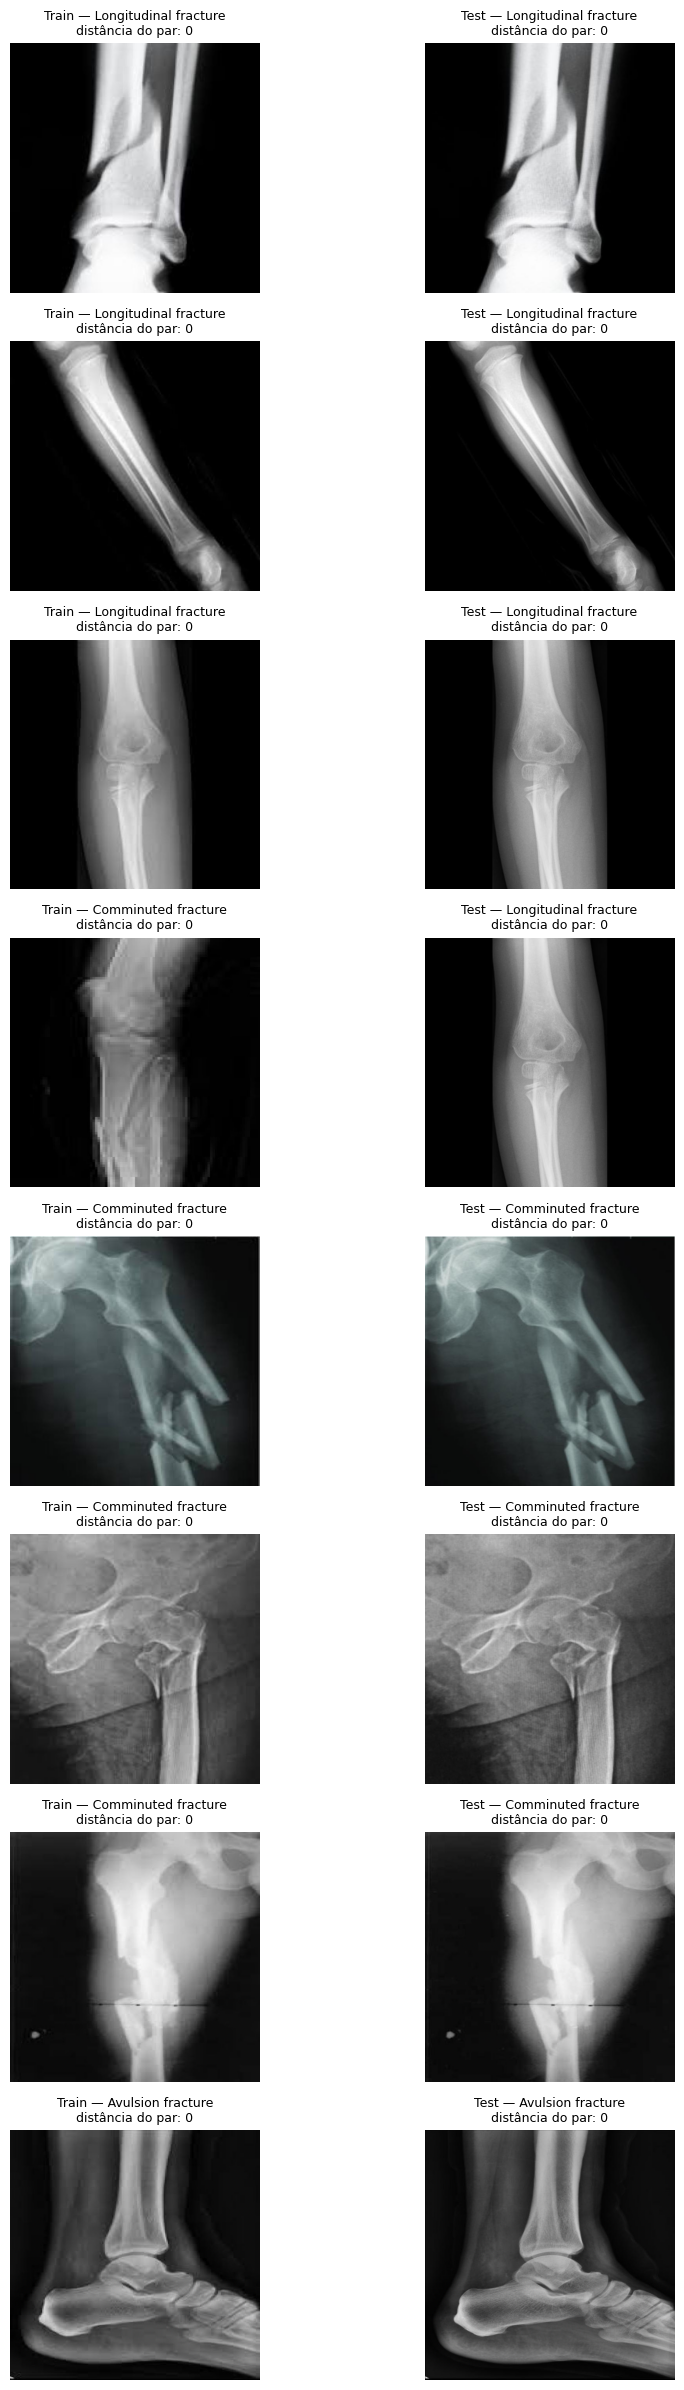

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

pares = suspeitas[:8]
fig, eixos = plt.subplots(len(pares), 2, figsize=(10, 3 * len(pares)))

for linha, (distancia, caminho_treino, caminho_teste) in enumerate(pares):
    for coluna, caminho in enumerate((caminho_treino, caminho_teste)):
        with Image.open(caminho) as imagem:
            eixos[linha, coluna].imshow(imagem.copy(), cmap="gray")
        eixos[linha, coluna].axis("off")
        eixos[linha, coluna].set_title(
            f"{'Train' if coluna == 0 else 'Test'} — "
            f"{caminho.parent.parent.name}\n"
            f"distância do par: {distancia}",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from PIL import Image

def diferenca_media(caminho_a, caminho_b):
    def carregar(caminho):
        with Image.open(caminho) as imagem:
            return np.asarray(
                imagem.convert("L").resize((128, 128)),
                dtype=np.float32
            ) / 255.0

    a, b = carregar(caminho_a), carregar(caminho_b)
    return float(np.mean(np.abs(a - b)))

comparacoes = sorted(
    (
        (diferenca_media(p1, p2), distancia, p1, p2)
        for distancia, p1, p2 in suspeitas
    ),
    key=lambda item: item[0]
)

print("Número de pares:", len(comparacoes))
print("Pares com diferença média < 0,01:",
      sum(erro < 0.01 for erro, *_ in comparacoes))
print("Pares com diferença média < 0,05:",
      sum(erro < 0.05 for erro, *_ in comparacoes))

print("\n10 pares mais semelhantes:")
for erro, distancia, p1, p2 in comparacoes[:10]:
    print(f"{erro:.4f} | hash {distancia} | "
          f"{p1.relative_to(raiz)} | {p2.relative_to(raiz)}")

Número de pares: 104
Pares com diferença média < 0,01: 16
Pares com diferença média < 0,05: 22

10 pares mais semelhantes:
0.0015 | hash 0 | Fracture Dislocation/Train/image2_jpeg.rf.bc16ebd39d77b02f60313cbb8c73a338.jpg | Fracture Dislocation/Test/847b5a158bed0311bf28b5cd647088_jumbo_jpg.rf.271ac7bed7b0dc447ad19199a5292c3d.jpg
0.0017 | hash 1 | Oblique fracture/Train/Inked220px-MalletFinger-Ppg.rf.8eb8b19e344b2ab4d48b4cbeda7b4a80_LI.jpg | Oblique fracture/Test/220px-MalletFinger-PNG_jpg.rf.8eb8b19e344b2ab4d48b4cbeda7b4a80.jpg
0.0022 | hash 0 | Longitudinal fracture/Train/image14_jpeg.rf.e7c94e1a17c793fbaf3c607c4904561b.jpg | Longitudinal fracture/Test/35d36ae9df9a48426f94b75d0f2939_jumbo_jpeg.rf.c0eebf1735c43ba5de01d321ce10748a.jpg
0.0024 | hash 0 | Longitudinal fracture/Train/image19_jpeg.rf.883f4884d8d4b625872a61ff5333c797.jpg | Longitudinal fracture/Test/488c4ff0bb5278bbf87f4c0e981dd6_gallery_jpg.rf.87d2f936037e0dfc1614f7518316a543.jpg
0.0026 | hash 0 | Longitudinal fracture/Train/i

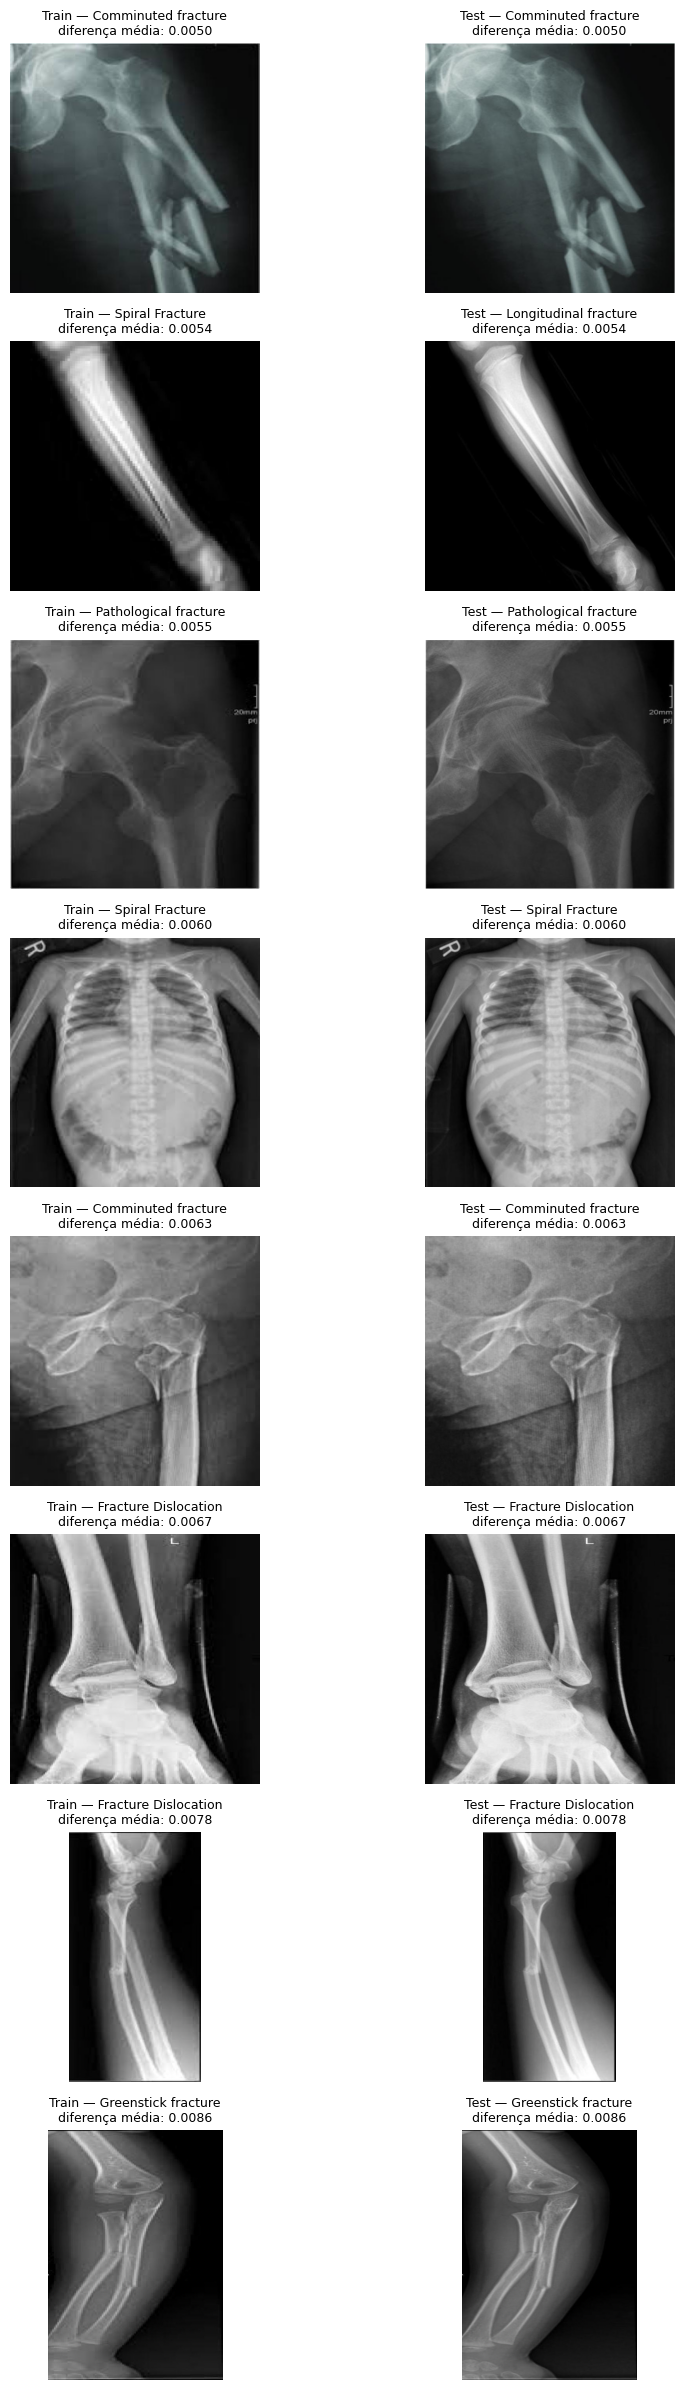

In [ ]:
pares_fortes = [item for item in comparacoes if item[0] < 0.01]
restantes = pares_fortes[8:16]

fig, eixos = plt.subplots(len(restantes), 2, figsize=(10, 3 * len(restantes)))

for linha, (erro, _, caminho_treino, caminho_teste) in enumerate(restantes):
    for coluna, caminho in enumerate((caminho_treino, caminho_teste)):
        with Image.open(caminho) as imagem:
            eixos[linha, coluna].imshow(imagem.copy(), cmap="gray")
        eixos[linha, coluna].axis("off")
        eixos[linha, coluna].set_title(
            f"{'Train' if coluna == 0 else 'Test'} — "
            f"{caminho.parent.parent.name}\n"
            f"diferença média: {erro:.4f}",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [ ]:
imagens = treino + teste
miniaturas = [
    (p, np.asarray(
        Image.open(p).convert("L").resize((128, 128)),
        dtype=np.float32
    ) / 255.0)
    for p in imagens
]

conflitos = []

for i, (p1, a) in enumerate(miniaturas):
    for p2, b in miniaturas[i + 1:]:
        if p1.parent.parent.name == p2.parent.parent.name:
            continue
        erro = float(np.mean(np.abs(a - b)))
        if erro < 0.01:
            conflitos.append((erro, p1, p2))

print("Pares muito semelhantes com classes diferentes:", len(conflitos))
for erro, p1, p2 in sorted(conflitos)[:20]:
    print(f"{erro:.4f} | {p1.relative_to(raiz)} | {p2.relative_to(raiz)}")

Pares muito semelhantes com classes diferentes: 9
0.0023 | Longitudinal fracture/Train/image24_jpeg.rf.497d0755d1e5bc96e3f209848b393018.jpg | Spiral Fracture/Train/images11_jpg.rf.4074e948c222b66e5c3dd9fa888c9936.jpg
0.0026 | Greenstick fracture/Train/greenstick_fracture_jpg.rf.bb53261c754308dac77549888aabbd56.jpg | Impacted fracture/Train/images45_jpg.rf.4228ce891b121aa6225cf13805647291.jpg
0.0035 | Impacted fracture/Train/images5_jpg.rf.9fb5f711b5100dd40430860528b8002f.jpg | Spiral Fracture/Train/image29_jpeg.rf.fa790c3f258afd479b9b994ecbd1c78d.jpg
0.0042 | Impacted fracture/Train/c0034602-spiral-fracture-of-the-distal-femur-science-photo-library-high_jpg.rf.6f1a6bd4e56c2f10c48ba98921ed533f.jpg | Spiral Fracture/Train/images11_jpg.rf.4074e948c222b66e5c3dd9fa888c9936.jpg
0.0045 | Longitudinal fracture/Train/image24_jpeg.rf.497d0755d1e5bc96e3f209848b393018.jpg | Impacted fracture/Train/c0034602-spiral-fracture-of-the-distal-femur-science-photo-library-high_jpg.rf.6f1a6bd4e56c2f10c48ba9

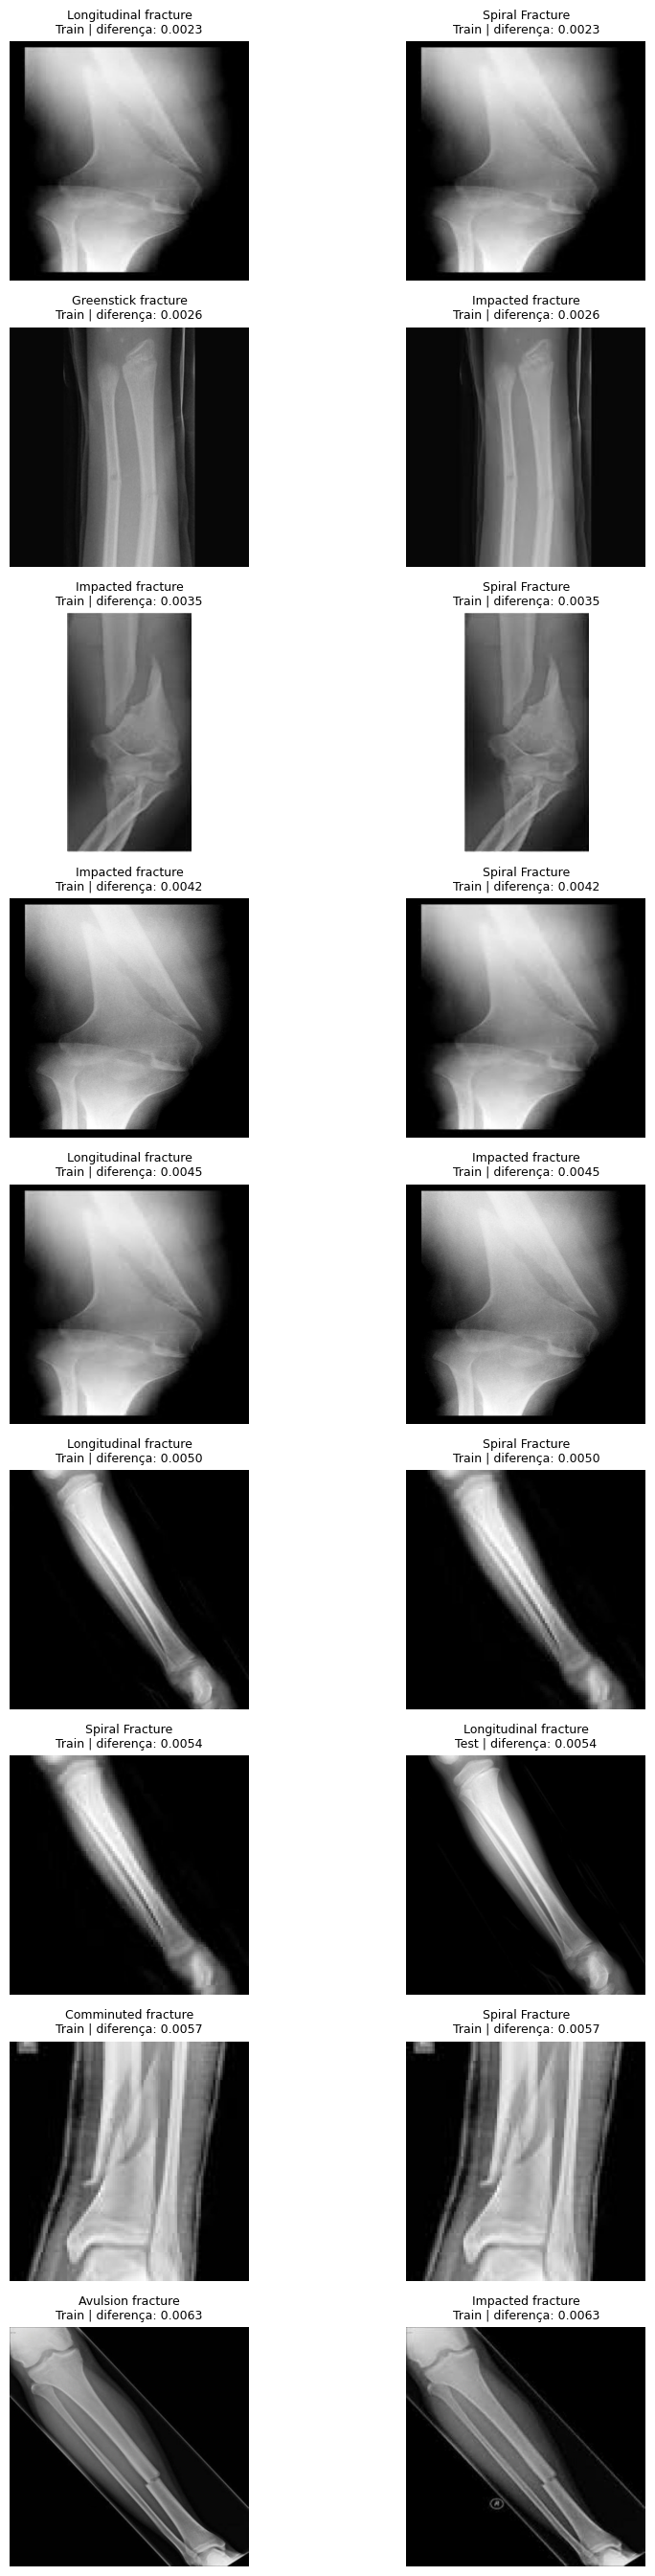

In [ ]:
fig, eixos = plt.subplots(len(conflitos), 2, figsize=(10, 3 * len(conflitos)))

for linha, (erro, p1, p2) in enumerate(sorted(conflitos)):
    for coluna, caminho in enumerate((p1, p2)):
        with Image.open(caminho) as imagem:
            eixos[linha, coluna].imshow(imagem.copy(), cmap="gray")
        eixos[linha, coluna].axis("off")
        eixos[linha, coluna].set_title(
            f"{caminho.parent.parent.name}\n"
            f"{caminho.parent.name} | diferença: {erro:.4f}",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [ ]:
# Agrupa imagens quase iguais; ainda não altera o dataset.
caminhos = [p for p, _ in miniaturas]
pai = list(range(len(caminhos)))

def encontrar(i):
    while pai[i] != i:
        pai[i] = pai[pai[i]]
        i = pai[i]
    return i

def unir(i, j):
    a, b = encontrar(i), encontrar(j)
    if a != b:
        pai[b] = a

hashes = [dhash(p) for p in caminhos]

for i in range(len(caminhos)):
    for j in range(i + 1, len(caminhos)):
        if (hashes[i] ^ hashes[j]).bit_count() > 4:
            continue
        erro = float(np.mean(np.abs(miniaturas[i][1] - miniaturas[j][1])))
        if erro < 0.01:
            unir(i, j)

from collections import defaultdict

grupos = defaultdict(list)
for i, caminho in enumerate(caminhos):
    grupos[encontrar(i)].append(caminho)

ambiguos = [
    grupo for grupo in grupos.values()
    if len({p.parent.parent.name for p in grupo}) > 1
]
repetidos_mesma_classe = [
    grupo for grupo in grupos.values()
    if len(grupo) > 1
    and len({p.parent.parent.name for p in grupo}) == 1
]

print("Grupos com rótulos conflitantes:", len(ambiguos))
print("Imagens nesses grupos:", sum(map(len, ambiguos)))
print("Grupos repetidos com a mesma classe:", len(repetidos_mesma_classe))
print("Cópias excedentes nesses grupos:",
      sum(len(g) - 1 for g in repetidos_mesma_classe))

Grupos com rótulos conflitantes: 6
Imagens nesses grupos: 14
Grupos repetidos com a mesma classe: 68
Cópias excedentes nesses grupos: 70


In [ ]:
from collections import Counter

amostra_limpa = []
excluidas_conflito = []

for grupo in grupos.values():
    classes = {p.parent.parent.name for p in grupo}

    if len(classes) > 1:
        excluidas_conflito.extend(grupo)
    else:
        # Guarda uma única imagem de cada grupo da mesma classe.
        amostra_limpa.append(sorted(grupo)[0])

contagem_limpa = Counter(p.parent.parent.name for p in amostra_limpa)

print("Imagens utilizáveis:", len(amostra_limpa))
print("Excluídas por conflito de rótulos:", len(excluidas_conflito))
print("\nImagens por classe:")
for classe, quantidade in sorted(contagem_limpa.items()):
    print(f"{classe}: {quantidade}")

Imagens utilizáveis: 1045
Excluídas por conflito de rótulos: 14

Imagens por classe:
Avulsion fracture: 120
Comminuted fracture: 130
Fracture Dislocation: 147
Greenstick fracture: 117
Hairline Fracture: 109
Impacted fracture: 74
Longitudinal fracture: 71
Oblique fracture: 80
Pathological fracture: 123
Spiral Fracture: 74


In [ ]:
import csv
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split

SEMENTE = 42

caminhos = sorted(amostra_limpa)
rotulos = [p.parent.parent.name for p in caminhos]

# Primeiro: 70% treino, 30% reservados.
x_treino, x_restante = train_test_split(
    caminhos,
    test_size=0.30,
    stratify=rotulos,
    random_state=SEMENTE
)

# Metade dos 30% para validação; metade para teste.
x_validacao, x_teste = train_test_split(
    x_restante,
    test_size=0.50,
    stratify=[p.parent.parent.name for p in x_restante],
    random_state=SEMENTE
)

conjuntos = {
    "treino": x_treino,
    "validacao": x_validacao,
    "teste": x_teste,
}

# Verificações antes de guardar.
assert sum(map(len, conjuntos.values())) == len(amostra_limpa)
assert len(set(x_treino) & set(x_validacao)) == 0
assert len(set(x_treino) & set(x_teste)) == 0
assert len(set(x_validacao) & set(x_teste)) == 0

saida = Path("/content/divisao_p1.csv")
with saida.open("w", newline="", encoding="utf-8") as ficheiro:
    escritor = csv.writer(ficheiro)
    escritor.writerow(["caminho_relativo", "classe", "conjunto"])
    for nome_conjunto, ficheiros in conjuntos.items():
        for caminho in sorted(ficheiros):
            escritor.writerow([
                str(caminho.relative_to(raiz)),
                caminho.parent.parent.name,
                nome_conjunto
            ])

for nome, ficheiros in conjuntos.items():
    print(f"\n{nome}: {len(ficheiros)} imagens")
    print(dict(sorted(Counter(
        p.parent.parent.name for p in ficheiros
    ).items())))

print(f"\nDivisão guardada em: {saida}")


treino: 731 imagens
{'Avulsion fracture': 84, 'Comminuted fracture': 91, 'Fracture Dislocation': 103, 'Greenstick fracture': 82, 'Hairline Fracture': 76, 'Impacted fracture': 52, 'Longitudinal fracture': 49, 'Oblique fracture': 56, 'Pathological fracture': 86, 'Spiral Fracture': 52}

validacao: 157 imagens
{'Avulsion fracture': 18, 'Comminuted fracture': 19, 'Fracture Dislocation': 22, 'Greenstick fracture': 18, 'Hairline Fracture': 16, 'Impacted fracture': 11, 'Longitudinal fracture': 11, 'Oblique fracture': 12, 'Pathological fracture': 19, 'Spiral Fracture': 11}

teste: 157 imagens
{'Avulsion fracture': 18, 'Comminuted fracture': 20, 'Fracture Dislocation': 22, 'Greenstick fracture': 17, 'Hairline Fracture': 17, 'Impacted fracture': 11, 'Longitudinal fracture': 11, 'Oblique fracture': 12, 'Pathological fracture': 18, 'Spiral Fracture': 11}

Divisão guardada em: /content/divisao_p1.csv


In [ ]:
from google.colab import files
files.download("/content/divisao_p1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"  # antes de importar keras

import keras
print("Keras:", keras.__version__)
print("Backend:", keras.config.backend())

!nvidia-smi

Keras: 3.13.2
Backend: tensorflow
Wed Sep 23 14:40:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------

In [6]:
from pathlib import Path

print("ZIP:", Path("/content/archive (3).zip").exists())
print("CSV:", Path("/content/divisao_p1.csv").exists())
print("Imagens extraídas:", Path(
    "/content/bone_break_data/Bone Break Classification/Bone Break Classification"
).exists())

ZIP: True
CSV: True
Imagens extraídas: False


In [7]:
from pathlib import Path
from zipfile import ZipFile

zip_path = Path("/content/archive (3).zip")
csv_path = Path("/content/divisao_p1.csv")
destino = Path("/content/bone_break_data")

assert zip_path.exists(), "Falta carregar archive (3).zip"
assert csv_path.exists(), "Falta carregar divisao_p1.csv"

with ZipFile(zip_path) as arquivo:
    arquivo.extractall(destino)

raiz = destino / "Bone Break Classification" / "Bone Break Classification"

print("CSV encontrado:", csv_path.exists())
print("Pasta das imagens encontrada:", raiz.exists())

CSV encontrado: True
Pasta das imagens encontrada: True


In [8]:
import csv
from collections import Counter

with open(csv_path, newline="", encoding="utf-8") as ficheiro:
    linhas = list(csv.DictReader(ficheiro))

faltantes = [
    linha["caminho_relativo"]
    for linha in linhas
    if not (raiz / linha["caminho_relativo"]).is_file()
]

rotulos_incorretos = [
    linha["caminho_relativo"]
    for linha in linhas
    if (raiz / linha["caminho_relativo"]).parent.parent.name != linha["classe"]
]

print("Registos no CSV:", len(linhas))
print("Por conjunto:", dict(Counter(linha["conjunto"] for linha in linhas)))
print("Imagens em falta:", len(faltantes))
print("Rótulos que não coincidem com a pasta:", len(rotulos_incorretos))

Registos no CSV: 1045
Por conjunto: {'treino': 731, 'validacao': 157, 'teste': 157}
Imagens em falta: 0
Rótulos que não coincidem com a pasta: 0


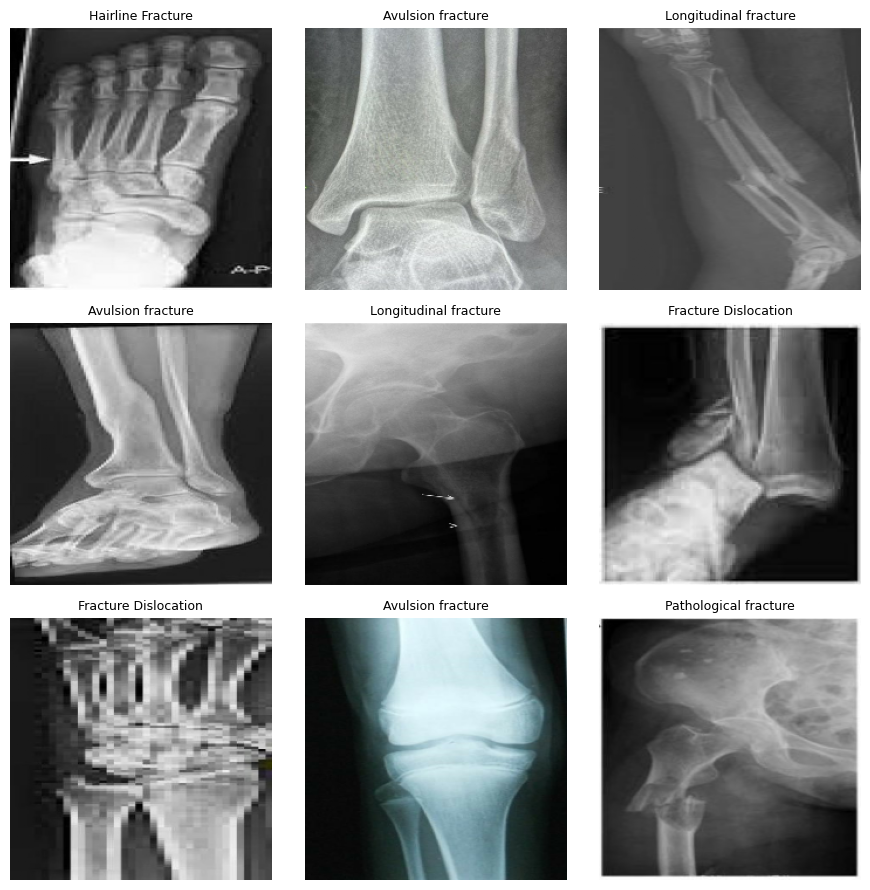

Shape do lote: (32, 224, 224, 3)
Classes: 10


In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt

classes = sorted({linha["classe"] for linha in linhas})
indice_classe = {classe: i for i, classe in enumerate(classes)}

def criar_dataset(nome_conjunto, embaralhar=False):
    selecionadas = [
        linha for linha in linhas
        if linha["conjunto"] == nome_conjunto
    ]
    caminhos = [
        str(raiz / linha["caminho_relativo"])
        for linha in selecionadas
    ]
    rotulos = [
        indice_classe[linha["classe"]]
        for linha in selecionadas
    ]

    ds = tf.data.Dataset.from_tensor_slices((caminhos, rotulos))

    if embaralhar:
        ds = ds.shuffle(
            buffer_size=len(caminhos),
            seed=42,
            reshuffle_each_iteration=True
        )

    def carregar_imagem(caminho, rotulo):
        dados = tf.io.read_file(caminho)
        imagem = tf.io.decode_jpeg(dados, channels=3)
        imagem = tf.image.resize(imagem, (224, 224))
        imagem = imagem / 255.0
        return imagem, rotulo

    return ds.map(
        carregar_imagem,
        num_parallel_calls=tf.data.AUTOTUNE
    ).batch(32).prefetch(tf.data.AUTOTUNE)

ds_treino = criar_dataset("treino", embaralhar=True)
ds_validacao = criar_dataset("validacao")
ds_teste = criar_dataset("teste")

imagens, rotulos = next(iter(ds_treino))

fig, eixos = plt.subplots(3, 3, figsize=(9, 9))
for i, eixo in enumerate(eixos.flat):
    eixo.imshow(imagens[i].numpy())
    eixo.set_title(classes[int(rotulos[i])], fontsize=9)
    eixo.axis("off")

plt.tight_layout()
plt.show()

print("Shape do lote:", imagens.shape)
print("Classes:", len(classes))

In [10]:
import keras

modelo = keras.Sequential([
    keras.layers.Input(shape=(224, 224, 3)),

    keras.layers.Conv2D(32, 3, activation="relu"),
    keras.layers.MaxPooling2D(),

    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D(),

    keras.layers.Conv2D(128, 3, activation="relu"),
    keras.layers.MaxPooling2D(),

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(len(classes), activation="softmax"),
])

modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,154 (399.04 KB)

 Trainable params: 102,154 (399.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
historico = modelo.fit(
    ds_treino,
    validation_data=ds_validacao,
    epochs=15,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 386ms/step - accuracy: 0.1368 - loss: 2.2920 - val_accuracy: 0.1401 - val_loss: 2.2803
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.1259 - loss: 2.2804 - val_accuracy: 0.1210 - val_loss: 2.2787
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.1395 - loss: 2.2715 - val_accuracy: 0.1401 - val_loss: 2.2706
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.1395 - loss: 2.2678 - val_accuracy: 0.1338 - val_loss: 2.2680
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.1491 - loss: 2.2640 - val_accuracy: 0.1338 - val_loss: 2.2609
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.1450 - loss: 2.2552 - val_accuracy: 0.1401 - val_loss: 2.2617
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.1518 - loss: 2.2496 - val_accuracy: 0.1401 - val_loss: 2.2512
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.1737 - loss: 2.2345 - val_accuracy: 0.1656 

“CNN treinada de raiz; melhor val_loss: 2,1330; melhor val_accuracy observada: 21,0%. Os pesos restaurados são os da época 10.”

In [11]:
import keras

base = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base.trainable = False

entrada = keras.Input(shape=(224, 224, 3))

# ds_treino já contém pixels entre 0 e 1.
# A MobileNetV2 espera valores entre 0 e 255 antes do seu preprocess_input.
x = keras.layers.Rescaling(255.0)(entrada)
x = keras.applications.mobilenet_v2.preprocess_input(x)

x = base(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
saida = keras.layers.Dense(len(classes), activation="softmax")(x)

modelo_transfer = keras.Model(entrada, saida)

modelo_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_transfer.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
historico_transfer = modelo_transfer.fit(
    ds_treino,
    validation_data=ds_validacao,
    epochs=15,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.1546 - loss: 2.4652 - val_accuracy: 0.1656 - val_loss: 2.4582
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.2791 - loss: 2.0081 - val_accuracy: 0.2357 - val_loss: 2.2731
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.3721 - loss: 1.7656 - val_accuracy: 0.2675 - val_loss: 2.1768
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.4555 - loss: 1.5912 - val_accuracy: 0.2994 - val_loss: 2.1619
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5294 - loss: 1.4321 - val_accuracy: 0.2675 - val_loss: 2.0948
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.6197 - loss: 1.3029 - val_accuracy: 0.2611 - val_loss: 2.0883
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.6512 - loss: 1.2099 - val_accuracy: 0.3376 - val_loss: 2.0348
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.6949 - loss: 1.1193 - val_accuracy: 0.3439 - va

A MobileNetV2 melhorou a validação face à CNN anterior: na parte visível, chegou a 35,0% na época 9, contra 21,0% da CNN. Mas a precisão de treino já está perto de 78% na época 11, enquanto a de validação ronda 33%. Essa diferença sugere que o modelo está a ajustar-se demasiado às imagens de treino.

In [13]:
h = historico_transfer.history
melhor_epoca = min(range(len(h["val_loss"])), key=lambda i: h["val_loss"][i])

print("Épocas executadas:", len(h["loss"]))
print("Época com menor val_loss:", melhor_epoca + 1)
print("Val_loss nessa época:", h["val_loss"][melhor_epoca])
print("Val_accuracy nessa época:", h["val_accuracy"][melhor_epoca])
print("Maior val_accuracy observada:", max(h["val_accuracy"]))

Épocas executadas: 11
Época com menor val_loss: 8
Val_loss nessa época: 2.029801845550537
Val_accuracy nessa época: 0.3439490497112274
Maior val_accuracy observada: 0.35031846165657043


In [14]:
modelo.save("/content/cnn_base.keras")
modelo_transfer.save("/content/mobilenetv2_transfer.keras")

print("Modelos guardados.")

Modelos guardados.


In [15]:
for nome, candidato in [
    ("CNN de raiz", modelo),
    ("MobileNetV2", modelo_transfer),
]:
    loss, accuracy = candidato.evaluate(ds_teste, verbose=0)
    print(f"{nome}: loss={loss:.4f} | accuracy={accuracy:.2%}")

CNN de raiz: loss=2.2965 | accuracy=12.74%
MobileNetV2: loss=1.8992 | accuracy=33.76%


No teste, a MobileNetV2 acertou 33,76% das 157 imagens; a CNN de raiz acertou 12,74%. A MobileNetV2 teve melhor desempenho, mas a precisão ainda é baixa para distinguir estes tipos de fratura. Estes são resultados de classificação neste dataset, não uma medida de fiabilidade clínica.

In [16]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from google.colab import files

nomes = [
    "cnn_base.keras",
    "mobilenetv2_transfer.keras",
    "divisao_p1.csv",
]

arquivos = [Path("/content") / nome for nome in nomes]
em_falta = [str(arquivo) for arquivo in arquivos if not arquivo.is_file()]

if em_falta:
    raise FileNotFoundError(f"Ficheiros não encontrados: {em_falta}")

destino = Path("/content/backup_p1.zip")

with ZipFile(destino, "w", compression=ZIP_DEFLATED) as zip_saida:
    for arquivo in arquivos:
        zip_saida.write(arquivo, arcname=arquivo.name)

print(f"Backup criado: {destino}")
files.download(str(destino))

Backup criado: /content/backup_p1.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descobrir quais clases confunde

In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

rotulos_reais = []
rotulos_previstos = []

for imagens, rotulos in ds_teste:
    probabilidades = modelo_transfer.predict(imagens, verbose=0)
    rotulos_reais.extend(rotulos.numpy())
    rotulos_previstos.extend(np.argmax(probabilidades, axis=1))

print(classification_report(
    rotulos_reais,
    rotulos_previstos,
    labels=range(len(classes)),
    target_names=classes,
    digits=3,
    zero_division=0
))

print("Matriz de confusão (linhas = classe real; colunas = previsão):")
print(confusion_matrix(
    rotulos_reais,
    rotulos_previstos,
    labels=range(len(classes))
))

                       precision    recall  f1-score   support

    Avulsion fracture      0.378     0.778     0.509        18
  Comminuted fracture      0.154     0.100     0.121        20
 Fracture Dislocation      0.318     0.318     0.318        22
  Greenstick fracture      0.387     0.706     0.500        17
    Hairline Fracture      0.667     0.235     0.348        17
    Impacted fracture      0.375     0.273     0.316        11
Longitudinal fracture      0.000     0.000     0.000        11
     Oblique fracture      0.111     0.083     0.095        12
Pathological fracture      0.350     0.389     0.368        18
      Spiral Fracture      0.500     0.273     0.353        11

             accuracy                          0.338       157
            macro avg      0.324     0.315     0.293       157
         weighted avg      0.332     0.338     0.307       157

Matriz de confusão (linhas = classe real; colunas = previsão):
[[14  0  0  0  1  1  0  1  1  0]
 [ 4  2  3  2  0  0

A CNN treinada de raiz obteve 12,74% de accuracy no teste. A MobileNetV2 com transfer learning obteve 33,76% de accuracy e F1 macro de 0,293, nas mesmas 157 imagens. Apesar da melhoria, o desempenho continua baixo: por exemplo, nenhuma das 11 imagens da classe Longitudinal fracture foi corretamente identificada. O dataset também apresentou imagens repetidas e rótulos conflitantes; foram removidos os casos detetados antes da divisão dos dados. Estes resultados não permitem utilizar o modelo para diagnóstico.